Step 9.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

import joblib

Step 9.2 Load Test Data

In [2]:
X_test = pd.read_csv("../data/processed/X_test_processed.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nTest target distribution:")
print(y_test.value_counts())

X_test shape: (1000, 30)
y_test shape: (1000,)

Test target distribution:
Fraudulent
0    904
1     96
Name: count, dtype: int64


Step 9.3 Load All Models

In [3]:
models = {
    "Logistic Regression": joblib.load("../models/logistic_regression_model.pkl"),
    "Decision Tree": joblib.load("../models/decision_tree_model.pkl"),
    "Random Forest": joblib.load("../models/random_forest_model.pkl"),
    "KNN": joblib.load("../models/knn_model.pkl"),
    "SVC": joblib.load("../models/svc_model.pkl")
}

print("Models loaded successfully:")

for name in models:
    print("-", name)

Models loaded successfully:
- Logistic Regression
- Decision Tree
- Random Forest
- KNN
- SVC


Step 9.4 Generate Predictions

In [4]:
predictions = {}
probabilities = {}

for name, model in models.items():
    predictions[name] = model.predict(X_test)
    probabilities[name] = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


Step 9.5 Calculate All Metrics

In [5]:
results = []

for name in models:

    y_pred = predictions[name]
    y_prob = probabilities[name]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.870,0.393750,0.656250,0.492188,0.799514
1,Decision Tree,0.886,0.418182,0.479167,0.446602,0.701604
2,Random Forest,0.894,0.451923,0.489583,0.470000,0.799387
3,KNN,0.737,0.196364,0.562500,0.291105,0.702232
4,SVC,0.881,0.388350,0.416667,0.402010,0.729224


Step 9.6 Percentage Format

In [6]:
results_percentage = results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

for col in metric_columns:
    results_percentage[col] = (
        results_percentage[col] * 100
    ).round(2)

results_percentage

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,87.0,39.38,65.62,49.22,79.95
1,Decision Tree,88.6,41.82,47.92,44.66,70.16
2,Random Forest,89.4,45.19,48.96,47.00,79.94
3,KNN,73.7,19.64,56.25,29.11,70.22
4,SVC,88.1,38.83,41.67,40.20,72.92


Step 9.7 Metrics Bar Chart

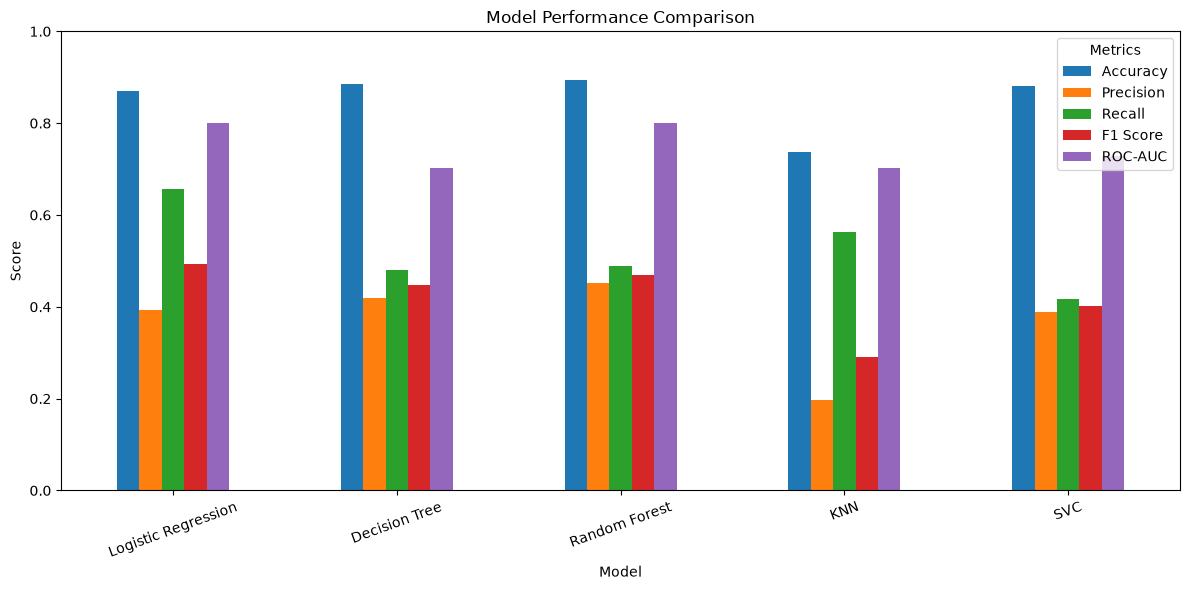

In [7]:
plot_df = results_df.set_index("Model")[metric_columns]

ax = plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)

plt.xticks(rotation=20)
plt.legend(title="Metrics")

plt.tight_layout()
plt.show()

Step 9.8 Confusion Matrices

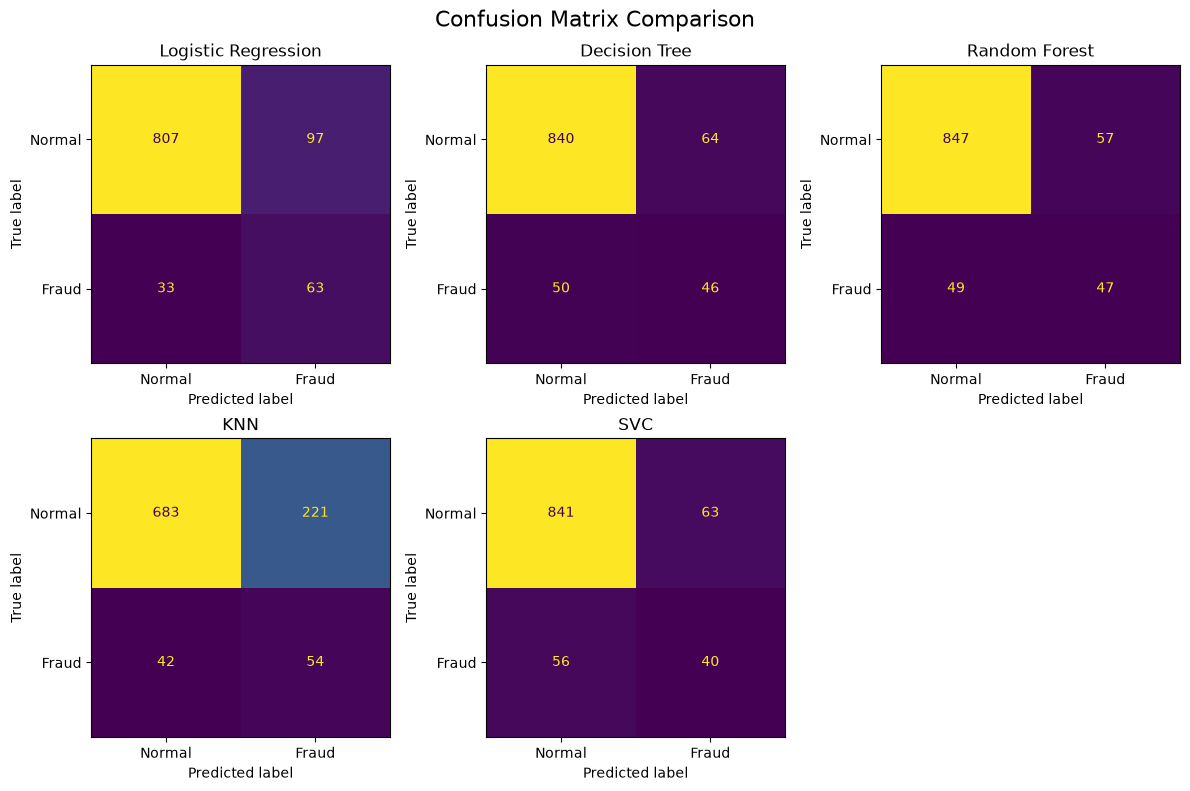

In [8]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(12, 8)
)

axes = axes.flatten()

for i, (name, y_pred) in enumerate(predictions.items()):

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Normal", "Fraud"]
    )

    disp.plot(
        ax=axes[i],
        values_format="d",
        colorbar=False
    )

    axes[i].set_title(name)

# Empty 6th subplot remove
axes[-1].axis("off")

plt.suptitle("Confusion Matrix Comparison", fontsize=16)

plt.tight_layout()
plt.show()

Step 9.9 ROC Curves

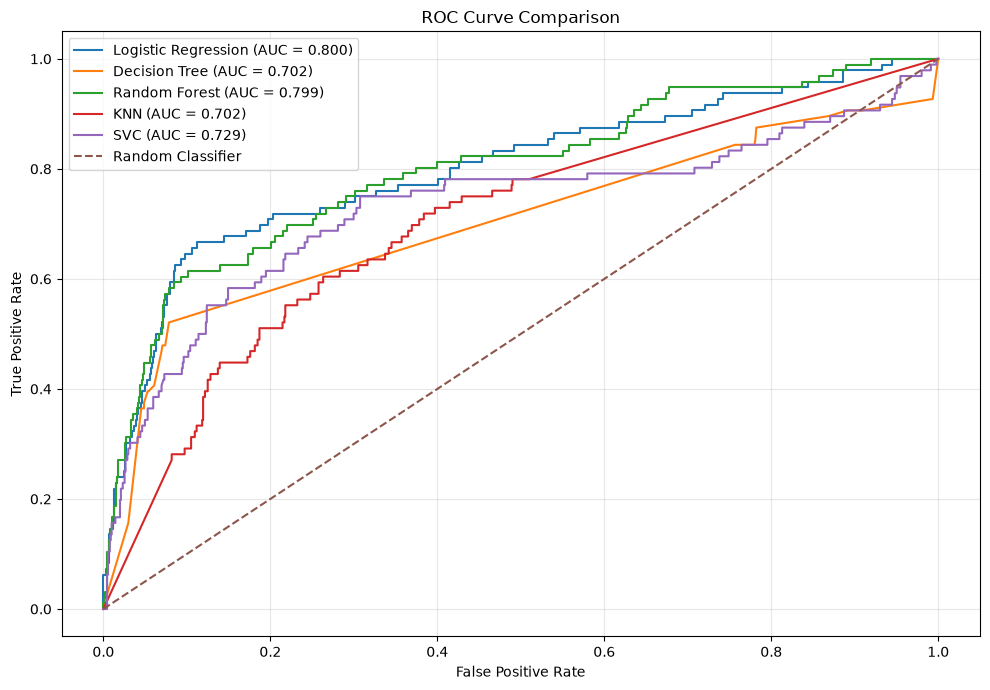

In [9]:
plt.figure(figsize=(10, 7))

for name in models:

    y_prob = probabilities[name]

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_prob
    )

    auc_score = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Step 9.10 Random Forest Feature Importance

In [10]:
rf_model = models["Random Forest"]

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
1,num__Is_International,0.166801
29,cat__Suspicious_Keyword_Yes,0.098881
28,cat__Suspicious_Keyword_No,0.093851
5,cat__Merchant_Category_Electronics,0.046838
15,cat__Payment_Method_NetBanking,0.038266
24,cat__Location_Hyderabad,0.036444
12,cat__Merchant_Category_Utilities,0.032912
7,cat__Merchant_Category_Fashion,0.029929
27,cat__Location_Pune,0.029173
9,cat__Merchant_Category_Grocery,0.027987


Step 9.11 Feature Importance Visualization

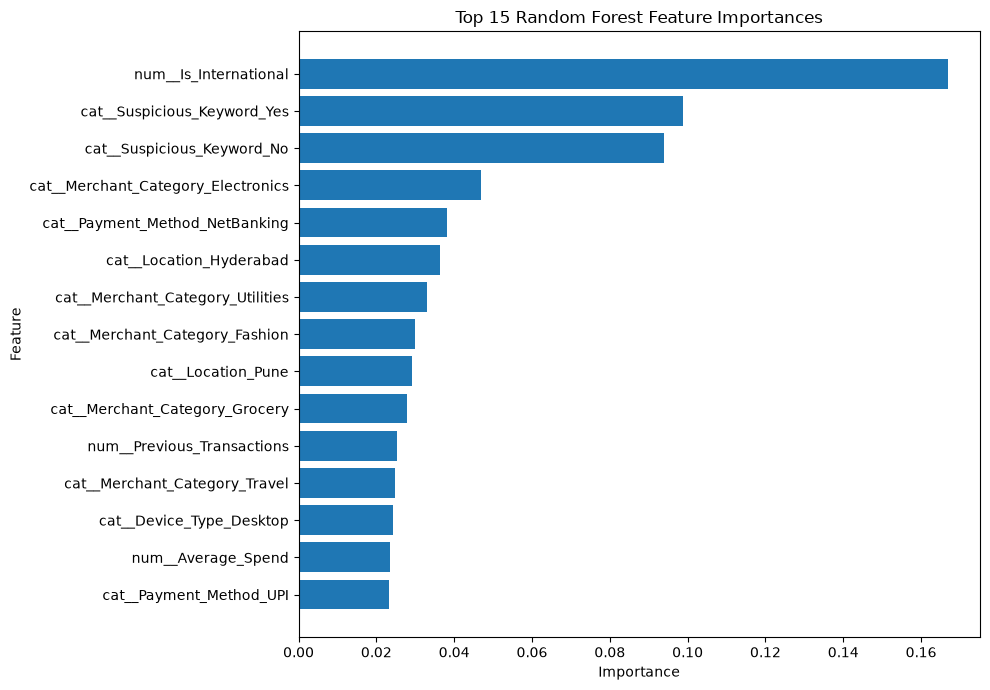

In [11]:
top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

Step 9.12 Save Evaluation Results

In [12]:
results_percentage.to_csv(
    "../data/processed/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


Step 9.13 Final Evaluation Summary

In [13]:
print("MODEL EVALUATION SUMMARY")
print("=" * 60)

for _, row in results_percentage.iterrows():

    print(f"\n{row['Model']}")
    print(f"Accuracy : {row['Accuracy']:.2f}%")
    print(f"Precision: {row['Precision']:.2f}%")
    print(f"Recall   : {row['Recall']:.2f}%")
    print(f"F1 Score : {row['F1 Score']:.2f}%")
    print(f"ROC-AUC  : {row['ROC-AUC']:.2f}%")

MODEL EVALUATION SUMMARY

Logistic Regression
Accuracy : 87.00%
Precision: 39.38%
Recall   : 65.62%
F1 Score : 49.22%
ROC-AUC  : 79.95%

Decision Tree
Accuracy : 88.60%
Precision: 41.82%
Recall   : 47.92%
F1 Score : 44.66%
ROC-AUC  : 70.16%

Random Forest
Accuracy : 89.40%
Precision: 45.19%
Recall   : 48.96%
F1 Score : 47.00%
ROC-AUC  : 79.94%

KNN
Accuracy : 73.70%
Precision: 19.64%
Recall   : 56.25%
F1 Score : 29.11%
ROC-AUC  : 70.22%

SVC
Accuracy : 88.10%
Precision: 38.83%
Recall   : 41.67%
F1 Score : 40.20%
ROC-AUC  : 72.92%
